In [1]:
# Kaggle dataset setup (comment out if dataset already in dataset/ folder)
# Each team member: add kaggle_username and kaggle_api_key as Colab secrets

from google.colab import userdata
import os
os.environ['KAGGLE_USERNAME'] = userdata.get('kaggle_username')
os.environ['KAGGLE_KEY'] = userdata.get('kaggle_api_key')
!kaggle datasets download -d threnjen/board-games-database-from-boardgamegeek -p dataset/ --unzip -q
!ls dataset/

Dataset URL: https://www.kaggle.com/datasets/threnjen/board-games-database-from-boardgamegeek
License(s): CC-BY-SA-3.0
artists_reduced.csv	    mechanics.csv	      themes.csv
bgg_data_documentation.txt  publishers_reduced.csv    user_ratings.csv
designers_reduced.csv	    ratings_distribution.csv
games.csv		    subcategories.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# Dataset

In [3]:
user_ratings_df = pd.read_csv('dataset/user_ratings.csv')
user_ratings_df.head(3)

,BGGId,Rating,Username
0,213788,8.0,Tonydorrf
1,213788,8.0,tachyon14k
2,213788,8.0,Ungotter


In [4]:
games_df = pd.read_csv('dataset/games.csv')
games_df.head(3)

,BGGId,Name,Description,YearPublished,GameWeight,AvgRating,BayesAvgRating,StdDev,MinPlayers,MaxPlayers,...,Rank:partygames,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens
0,1,Die Macher,die macher game seven sequential political rac...,1986,4.3206,7.61428,7.10363,1.57979,3,5,...,21926,21926,0,1,0,0,0,0,0,0
1,2,Dragonmaster,dragonmaster tricktaking card game base old ga...,1981,1.9630,6.64537,5.78447,1.45440,3,4,...,21926,21926,0,1,0,0,0,0,0,0
2,3,Samurai,samurai set medieval japan player compete gain...,1998,2.4859,7.45601,7.23994,1.18227,2,4,...,21926,21926,0,1,0,0,0,0,0,0


In [5]:
themes_df = pd.read_csv('dataset/themes.csv')
themes_df.head(3)

,BGGId,Adventure,Fantasy,Fighting,Environmental,Medical,Economic,Industry / Manufacturing,Transportation,Science Fiction,...,Theme_Fashion,Theme_Geocaching,Theme_Ecology,Theme_Chernobyl,Theme_Photography,Theme_French Foreign Legion,Theme_Cruise ships,Theme_Apache Tribes,Theme_Rivers,Theme_Flags identification
0,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
mechanics_df = pd.read_csv('dataset/mechanics.csv')
mechanics_df.head(3)

,BGGId,Alliances,Area Majority / Influence,Auction/Bidding,Dice Rolling,Hand Management,Simultaneous Action Selection,Trick-taking,Hexagon Grid,Once-Per-Game Abilities,...,Contracts,Passed Action Token,King of the Hill,Action Retrieval,Force Commitment,Rondel,Automatic Resource Growth,Legacy Game,Dexterity,Physical
0,1,1,1,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,0,1,0,0,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0


In [7]:
subcategories_df = pd.read_csv('dataset/subcategories.csv')
subcategories_df.head(3)

,BGGId,Exploration,Miniatures,Territory Building,Card Game,Educational,Puzzle,Collectible Components,Word Game,Print & Play,Electronic
0,1,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,1,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,0,0


In [8]:
designers_reduced_df = pd.read_csv('dataset/designers_reduced.csv')
designers_reduced_df.head(3)

,Karl-Heinz Schmiel,"G. W. ""Jerry"" D'Arcey",Reiner Knizia,Sid Sackson,Jean du Poël,Martin Wallace,Richard Ulrich,Wolfgang Kramer,Alan R. Moon,Uwe Rosenberg,...,Thomas Dupont,Mathieu Casnin,Sean Fletcher,Moritz Dressler,Molly Johnson,Robert Melvin,Shawn Stankewich,Nathan Meunier,BGGId,Low-Exp Designer
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3,0


In [9]:
publishers_reduced_df = pd.read_csv('dataset/publishers_reduced.csv')
publishers_reduced_df.head(3)

,Hans im Glück,Moskito Spiele,Portal Games,Spielworxx,Stronghold Games,"Valley Games, Inc.",YOKA Games,sternenschimmermeer,E.S. Lowe,Milton Bradley,...,Cacahuete Games,BlackSands Games,Norsker Games,Perro Loko Games,Funko Games,Origame,Deep Print Games,Hidden Industries GmbH,BGGId,Low-Exp Publisher
0,1,1,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,2,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3,1


In [10]:
ratings_distribution_df = pd.read_csv('dataset/ratings_distribution.csv')
ratings_distribution_df.head(3)

,BGGId,0.0,0.1,0.5,1.0,1.1,1.2,1.3,1.4,1.5,...,9.2,9.3,9.4,9.5,9.6,9.7,9.8,9.9,10.0,total_ratings
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,11.0,5.0,11.0,86.0,3.0,4.0,6.0,8.0,426.0,5352.0
1,2,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,17.0,562.0
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,20.0,7.0,4.0,77.0,3.0,1.0,5.0,3.0,477.0,15148.0


# Statistics

In [11]:
# Total number of interactions
user_ratings_df.shape

(18942215, 3)

In [12]:
# Number of users and games
user_ratings_df.nunique()

,0
BGGId,21925
Rating,10647
Username,411374


In [13]:
# Density
observed_ratings = user_ratings_df.shape[0]
possible_ratings = user_ratings_df['Username'].nunique() * user_ratings_df['BGGId'].nunique()
density = observed_ratings / possible_ratings * 100
print('Density: ', density)

Density:  0.21001693692754173


In [14]:
# Average number of ratings per user
avg_user_interactions = user_ratings_df['Username'].value_counts().mean()
print('Average interactions per user: ', avg_user_interactions)


Average interactions per user:  46.046060276050504


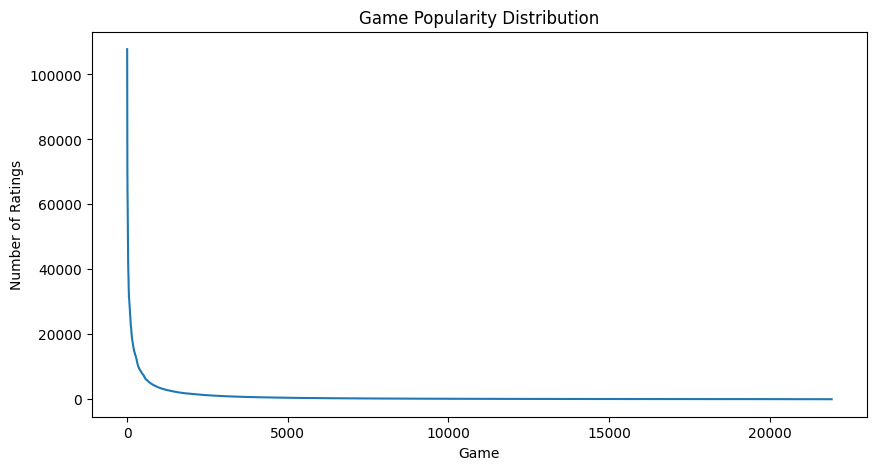

In [15]:
item_counts = user_ratings_df.groupby('BGGId')['Rating'].count().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.plot(item_counts.values)
plt.title('Game Popularity Distribution')
plt.xlabel('Game')
plt.ylabel('Number of Ratings')
plt.show()


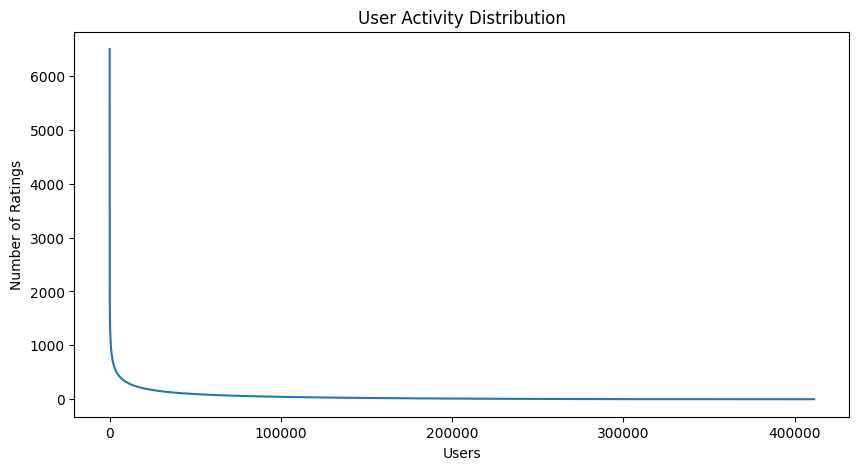

In [16]:
user_activity = user_ratings_df.groupby('Username')['Rating'].count().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(user_activity.index, user_activity['Rating'])

plt.title('User Activity Distribution')
plt.xlabel('Users')
plt.ylabel('Number of Ratings')
plt.show()


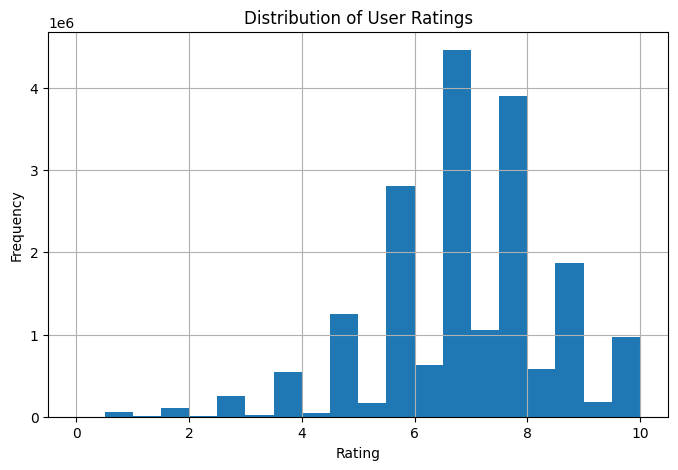

In [17]:
# Plot distribution of ratings
plt.figure(figsize=(8,5))
user_ratings_df['Rating'].hist(bins=20)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of User Ratings')
plt.show()

In [18]:
user_ratings_df['Rating'].describe()

,Rating
count,1.894222e+07
mean,7.130957e+00
std,1.543023e+00
min,1.000000e-04
25%,6.000000e+00
50%,7.000000e+00
75%,8.000000e+00
max,1.000000e+01


Ratings are mostly positive and cluster around 6-8. Hence, normalize ratings were added to remove individual user bias in rating behavior.

In [19]:
# Added Normalized ratings
user_mean = user_ratings_df.groupby('Username')['Rating'].transform('mean')

user_ratings_df['Rating_normalized'] = user_ratings_df['Rating'] - user_mean

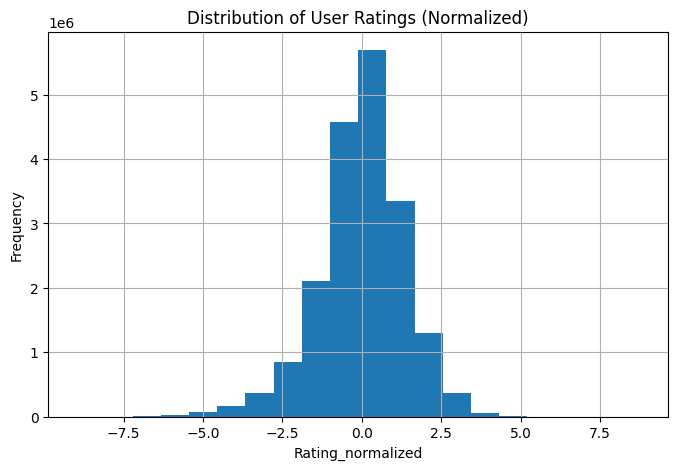

In [20]:
# Plot distribution of Normalized ratings
plt.figure(figsize=(8,5))
user_ratings_df['Rating_normalized'].hist(bins=20)
plt.xlabel('Rating_normalized')
plt.ylabel('Frequency')
plt.title('Distribution of User Ratings (Normalized)')
plt.show()

In [21]:
# Check if there are games with zero ratings
games_with_ratings = user_ratings_df['BGGId'].unique()
no_rating_games = games_df[~games_df['BGGId'].isin(games_with_ratings)]
print(f'Number of games with no ratings: {len(no_rating_games)}')

Number of games with no ratings: 0


# Data Cleaning

In [22]:
# Check for missing values
user_ratings_df.isna().sum()

,0
BGGId,0
Rating,0
Username,63
Rating_normalized,63


In [23]:
user_ratings_df = user_ratings_df.dropna(subset=['Username'])

Username is important for Collaborative filtering techniques and hence the missing interactions are dropped from the table.

In [24]:
games_df.isna().sum()

,0
BGGId,0
Name,0
Description,1
YearPublished,0
GameWeight,0
AvgRating,0
BayesAvgRating,0
StdDev,0
MinPlayers,0
MaxPlayers,0


List of missing columns :
1) ComAgeRec (Community's recommended age minimum) - not necessary since user information is not available, manufacturers' recommended age is available
2) LanguageEase (Language requirement) - not neccessary unless modeling user language preferences
3) Family (Game Family) - too many missing values
4) ImagePath (Image) - not userful for recommender system)

In [25]:
games_df = games_df.drop(columns=['Family', 'ComAgeRec', 'LanguageEase', 'ImagePath'])

In [26]:
# Check for duplicates
user_ratings_df.duplicated().sum()

np.int64(0)

In [27]:
games_df.duplicated().sum()

np.int64(0)

In [28]:
games_df.columns

Index(['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight',
       'AvgRating', 'BayesAvgRating', 'StdDev', 'MinPlayers', 'MaxPlayers',
       'BestPlayers', 'GoodPlayers', 'NumOwned', 'NumWant', 'NumWish',
       'NumWeightVotes', 'MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime',
       'MfgAgeRec', 'NumUserRatings', 'NumComments', 'NumAlternates',
       'NumExpansions', 'NumImplementations', 'IsReimplementation',
       'Kickstarted', 'Rank:boardgame', 'Rank:strategygames', 'Rank:abstracts',
       'Rank:familygames', 'Rank:thematic', 'Rank:cgs', 'Rank:wargames',
       'Rank:partygames', 'Rank:childrensgames', 'Cat:Thematic',
       'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS', 'Cat:Abstract',
       'Cat:Party', 'Cat:Childrens'],
      dtype='object')

In [29]:
# Drop other unneccessary features
features_to_drop = ['BestPlayers', 'GoodPlayers', 'NumWeightVotes',
       'NumAlternates', 'NumExpansions', 'NumImplementations',
       'IsReimplementation']

BestPlayers, GoodPlayers and NumWeightVotes were removed because they do not represent game characteristics. Other features like NumAlternates, NumExpansions, NumImplementations, and IsReimplementation were excluded as they have weak relevance to user preference.

In [30]:
games_df = games_df.drop(columns=features_to_drop)

# Filtering

Drop users with fewer than 5 ratings and games with fewer than 10 ratings. Applied iteratively until stable.

In [31]:
def filter_interactions(df, min_user=5, min_item=10):
    prev = -1
    while len(df) != prev:
        prev = len(df)
        user_counts = df.groupby('Username')['BGGId'].count()
        df = df[df['Username'].isin(user_counts[user_counts >= min_user].index)]
        item_counts = df.groupby('BGGId')['Username'].count()
        df = df[df['BGGId'].isin(item_counts[item_counts >= min_item].index)]
    return df.reset_index(drop=True)

print(f'Before: {len(user_ratings_df):,} interactions, {user_ratings_df["Username"].nunique():,} users, {user_ratings_df["BGGId"].nunique():,} games')
user_ratings_df = filter_interactions(user_ratings_df)
print(f'After:  {len(user_ratings_df):,} interactions, {user_ratings_df["Username"].nunique():,} users, {user_ratings_df["BGGId"].nunique():,} games')

Before: 18,942,152 interactions, 411,374 users, 21,925 games
After:  18,696,346 interactions, 272,184 users, 21,922 games


# ID Remapping

Map usernames and BGGIds to 0-indexed integers. Required by all models for embedding lookups.

In [32]:
unique_users = sorted(user_ratings_df['Username'].unique())
unique_items = sorted(user_ratings_df['BGGId'].unique())

user2idx = {u: i for i, u in enumerate(unique_users)}
item2idx = {g: i for i, g in enumerate(unique_items)}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: g for g, i in item2idx.items()}

user_ratings_df['user_idx'] = user_ratings_df['Username'].map(user2idx)
user_ratings_df['item_idx'] = user_ratings_df['BGGId'].map(item2idx)

print(f'n_users: {len(user2idx):,}')
print(f'n_items: {len(item2idx):,}')

n_users: 272,184
n_items: 21,922


# Train / Validation / Test Split

Leave-one-out protocol: last interaction per user → test, second-to-last → validation, rest → train.

In [33]:
train_rows, val_rows, test_rows = [], [], []

for uid, group in user_ratings_df.groupby('user_idx', sort=False):
    idxs = group.index.tolist()
    if len(idxs) < 3:
        train_rows.extend(idxs)
        continue
    test_rows.append(idxs[-1])
    val_rows.append(idxs[-2])
    train_rows.extend(idxs[:-2])

train_df = user_ratings_df.loc[train_rows].reset_index(drop=True)
val_df   = user_ratings_df.loc[val_rows].reset_index(drop=True)
test_df  = user_ratings_df.loc[test_rows].reset_index(drop=True)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Train: 18,151,978 | Val: 272,184 | Test: 272,184


# Export dataset

In [35]:
!mkdir -p dataset/processed

In [36]:
games_df.to_csv('dataset/processed/games_cleaned.csv', index=False)
train_df.to_csv('dataset/processed/train.csv', index=False)
val_df.to_csv('dataset/processed/val.csv', index=False)
test_df.to_csv('dataset/processed/test.csv', index=False)

with open('dataset/processed/id_maps.pkl', 'wb') as f:
    pickle.dump({'user2idx': user2idx, 'item2idx': item2idx,
                 'idx2user': idx2user, 'idx2item': idx2item}, f)

print('Saved to dataset/processed/')

Saved to dataset/processed/


In [37]:
user_ratings_df.to_csv('dataset/processed/user_ratings_cleaned.csv', index=False)
print('Done.')

Done.


# Save Processed Data to Google Drive

In [41]:
# Zip and upload processed folder to Google Drive
from google.colab import drive
import shutil, os

drive.mount('/content/drive')

# Create the team folder in your Drive if it doesn't exist
drive_folder = '/content/drive/MyDrive/CMPE256_Team8'
os.makedirs(drive_folder, exist_ok=True)

# Zip the processed folder
shutil.make_archive('processed', 'zip', 'dataset/', 'processed')
print('Zipped: processed.zip')

# Copy to Drive
shutil.copy('processed.zip', f'{drive_folder}/processed.zip')
print(f'Uploaded to {drive_folder}/processed.zip')

Mounted at /content/drive
Zipped: processed.zip
Uploaded to /content/drive/MyDrive/CMPE256_Team8/processed.zip


## Loading Processed Dataset from Drive in other notebooks

In [ ]:
import gdown, zipfile, os

FILE_ID = '1a7kCwqP2Vhlv43eep0ODdzGVR6v2ouP6'

gdown.download(id=FILE_ID, output='processed.zip', quiet=False, fuzzy=True)

with zipfile.ZipFile('processed.zip', 'r') as z:
    z.extractall('dataset/')

os.remove('processed.zip')
print('Ready. Files in dataset/processed/:')
print(os.listdir('dataset/processed/'))

**Files in processed dataset:**

- **`user_ratings_cleaned.csv`** — the full filtered interaction table with `user_idx` and `item_idx` added, normalized ratings included. This is the main interactions file all models work from.

- **`games_cleaned.csv`** — game metadata with irrelevant columns dropped (Family, ImagePath, etc.). Used for content features and the LLM-hybrid variant.

- **`train.csv`** — training interactions, all but the last 2 interactions per user.

- **`val.csv`** — one interaction per user (second-to-last). Used during model training to tune hyperparameters.

- **`test.csv`** — one interaction per user (last interaction). Only touched for final evaluation, never during training.

- **`id_maps.pkl`** — the four dictionaries: `user2idx`, `item2idx`, `idx2user`, `idx2item`. Load this to convert between original usernames/BGGIds and the integer indices the models use.